# 02b. Validación espacial — ¿se solapan los rásteres?

Auditoría geométrica del dataset de chips de garimpo. El objetivo es demostrar,
usando **únicamente las coordenadas** registradas en el manifiesto, que:

- los 12 rásteres de origen (`tif_source`) cubren **áreas geográficas distintas** y no
  son recortes superpuestos de la misma escena,
- **ningún chip se repite** ni se solapa con otro (ni dentro del mismo ráster, ni entre rásteres),
- **ningún chip aparece en más de una partición** de `train` / `val` / `test`.

Este cuaderno es de **solo lectura** sobre los datos ya generados: no modifica manifiestos
ni splits. Complementa a `01_eda_dataset` (calidad del dataset) y a `02_preprocessing`
(split por ráster), y se ejecuta antes de `03_feature_engineering`.

Cada comprobación se registra en un informe final con veredicto `OK`, `AVISO` o `FALLO`.

## 1. Configuración

In [1]:
import hashlib
import itertools
import re
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

# ── Rutas ──────────────────────────────────────────────────────────────────
DATA_RAW = Path("../data/01_raw")
DATA_INTERMEDIATE = Path("../data/02_intermediate")
DATA_MODEL_INPUT = Path("../data/05_model_input")
DATA_REPORTING = Path("../data/08_reporting")
FIGURES_DIR = Path("../reports/figures")

MANIFEST_RAW = DATA_RAW / "manifesto_chips.csv"
MANIFEST_SPLIT = DATA_INTERMEDIATE / "manifest_with_split.csv"
RASTER_SPLIT_MAP = DATA_INTERMEDIATE / "raster_split_map.csv"
CHIPS_DIR = DATA_RAW / "dataset_amazonia_garimpo_binario"

# ── Parámetros de la auditoría ─────────────────────────────────────────────
SPLITS = ("train", "val", "test")
SPLIT_CODES = {"train": 1, "val": 2, "test": 3}
SPLIT_COLORS = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}

TILE_SIZE_PX = 128              # lado del chip en píxeles
S2_PIXEL_M = 10                 # resolución nominal Sentinel-2 (m/píxel)
CHIP_SIDE_M = TILE_SIZE_PX * S2_PIXEL_M

GEO_TOL = 1e-9                  # tolerancia en grados para comparar coordenadas
DEDUP_DECIMALS = (6, 5, 4, 3)   # niveles de redondeo para buscar centroides repetidos
BUFFER_STEPS = (1, 2, 4, 8)     # buffers (en chips) a evaluar en las costuras
HASH_SAMPLE_PER_RASTER = 100    # chips por ráster para el hash de píxeles
RANDOM_STATE = 42

DATA_REPORTING.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Registro de comprobaciones ─────────────────────────────────────────────
CHECKS: list[dict[str, str]] = []


def registrar(test: str, estado: str, detalle: str) -> None:
    """Añade el resultado de una comprobación al informe final."""
    assert estado in {"OK", "AVISO", "FALLO"}, f"Estado inválido: {estado}"
    CHECKS.append({"test": test, "estado": estado, "detalle": detalle})
    print(f"[{estado}] {test} — {detalle}")


print(f"Chip: {TILE_SIZE_PX} px  ->  {CHIP_SIDE_M} m de lado (aprox, Sentinel-2 10 m)")
print(f"Manifiesto crudo    : {MANIFEST_RAW}")
print(f"Manifiesto con split: {MANIFEST_SPLIT}")

Chip: 128 px  ->  1280 m de lado (aprox, Sentinel-2 10 m)
Manifiesto crudo    : ..\data\01_raw\manifesto_chips.csv
Manifiesto con split: ..\data\02_intermediate\manifest_with_split.csv


## 2. Carga del manifiesto y de los splits

El manifiesto crudo (`manifesto_chips.csv`) es el único artefacto que contiene la geometría
completa de cada chip: bounding box en grados (`xmin`, `ymin`, `xmax`, `ymax`), bounding box
métrico UTM (`xmin_m`, …), centroide (`centroid_lon`, `centroid_lat`) y la transformación
afín del ráster de origen. El split se recupera de `manifest_with_split.csv` y se une por
`png_path`.

In [2]:
raw = pd.read_csv(MANIFEST_RAW)
splits = pd.read_csv(MANIFEST_SPLIT)[["png_path", "split"]]

df = raw.merge(splits, on="png_path", how="left", validate="one_to_one")

print(f"Chips en manifiesto crudo : {len(raw):,}")
print(f"Chips con split asignado  : {df['split'].notna().sum():,}")
print(f"Rásteres únicos           : {df['tif_source'].nunique()}")
print(f"CRS de los rásteres       : {df['crs_raster'].unique().tolist()}")
print(f"EPSG UTM de referencia    : {df['utm_epsg'].unique().tolist()}")
print(f"Tamaño de chip (px)       : {df['tile_size_px'].unique().tolist()}")
print(f"Bandas                    : {df['bands_used'].unique().tolist()}")

df[["png_path", "tif_source", "label_str", "split", "tile_row", "tile_col",
    "xmin", "ymin", "xmax", "ymax"]].head()

Chips en manifiesto crudo : 111,584
Chips con split asignado  : 111,584
Rásteres únicos           : 12
CRS de los rásteres       : ['EPSG:4326']
EPSG UTM de referencia    : [32721]
Tamaño de chip (px)       : [128]
Bandas                    : ["['B4', 'B3', 'B2']"]


,png_path,tif_source,label_str,split,tile_row,tile_col,xmin,ymin,xmax,ymax
0,sem_garimpo/v3_new_ret_s2_median_2024_dry-0000...,v3_new_ret_s2_median_2024_dry-0000000000-00000...,sem_garimpo,train,0,0,-58.338661,-4.507297,-58.327162,-4.495799
1,sem_garimpo/v3_new_ret_s2_median_2024_dry-0000...,v3_new_ret_s2_median_2024_dry-0000000000-00000...,sem_garimpo,train,0,1,-58.327162,-4.507297,-58.315664,-4.495799
2,sem_garimpo/v3_new_ret_s2_median_2024_dry-0000...,v3_new_ret_s2_median_2024_dry-0000000000-00000...,sem_garimpo,train,0,2,-58.315664,-4.507297,-58.304165,-4.495799
3,sem_garimpo/v3_new_ret_s2_median_2024_dry-0000...,v3_new_ret_s2_median_2024_dry-0000000000-00000...,sem_garimpo,train,0,3,-58.304165,-4.507297,-58.292667,-4.495799
4,sem_garimpo/v3_new_ret_s2_median_2024_dry-0000...,v3_new_ret_s2_median_2024_dry-0000000000-00000...,sem_garimpo,train,0,4,-58.292667,-4.507297,-58.281168,-4.495799


In [3]:
GEOM_COLS = ["xmin", "ymin", "xmax", "ymax", "centroid_lon", "centroid_lat"]

sin_split = int(df["split"].isna().sum())
nulos_geom = int(df[GEOM_COLS].isna().sum().sum())

registrar(
    "0. Integridad de la geometría",
    "OK" if (sin_split == 0 and nulos_geom == 0) else "FALLO",
    f"{sin_split} chips sin split, {nulos_geom} valores nulos en columnas de coordenadas",
)

degenerados = int(((df["xmax"] <= df["xmin"]) | (df["ymax"] <= df["ymin"])).sum())
registrar(
    "0b. Bounding boxes válidas",
    "OK" if degenerados == 0 else "FALLO",
    f"{degenerados} bounding boxes degeneradas (xmax<=xmin o ymax<=ymin)",
)

[OK] 0. Integridad de la geometría — 0 chips sin split, 0 valores nulos en columnas de coordenadas
[OK] 0b. Bounding boxes válidas — 0 bounding boxes degeneradas (xmax<=xmin o ymax<=ymin)


## 3. Decodificación de la rejilla de exportación

Los nombres de los `.tif` siguen el patrón de exportación de Google Earth Engine:

```text
v3_new_ret_s2_median_2024_dry-<offset_A>-<offset_B>.tif
```

Los dos números son desplazamientos **en píxeles** dentro del ráster original. Para poder
razonar sobre el mosaico hay que saber cuál de los dos es el eje X (longitud) y cuál el eje Y
(latitud); lo determinamos contrastando los offsets con los `xmin` / `ymax` reales en lugar
de asumirlo.

In [4]:
OFFSET_RE = re.compile(r"-(\d{10})-(\d{10})\.tif$")


def decode_offsets(tif_name: str) -> tuple[int, int]:
    """Extrae los dos offsets en píxeles del nombre del .tif."""
    match = OFFSET_RE.search(tif_name)
    if match is None:
        raise ValueError(f"Nombre de ráster inesperado: {tif_name}")
    return int(match.group(1)), int(match.group(2))


nombres = df["tif_source"].unique()
offsets = pd.DataFrame(
    [decode_offsets(name) for name in nombres],
    index=pd.Index(nombres, name="tif_source"),
    columns=["offset_a", "offset_b"],
)

bounds = df.groupby("tif_source").agg(
    xmin=("xmin", "min"), xmax=("xmax", "max"),
    ymin=("ymin", "min"), ymax=("ymax", "max"),
)
probe = offsets.join(bounds)

# Correlación de cada offset con la longitud y la latitud
corr_a_x = probe["offset_a"].corr(probe["xmin"])
corr_b_x = probe["offset_b"].corr(probe["xmin"])

if abs(corr_b_x) > abs(corr_a_x):
    X_OFFSET_COL, Y_OFFSET_COL = "offset_b", "offset_a"
else:
    X_OFFSET_COL, Y_OFFSET_COL = "offset_a", "offset_b"

print(f"corr(offset_a, xmin) = {corr_a_x:+.4f}")
print(f"corr(offset_b, xmin) = {corr_b_x:+.4f}")
print(f"\n-> el eje X (longitud) lo marca '{X_OFFSET_COL}'")
print(f"-> el eje Y (latitud)  lo marca '{Y_OFFSET_COL}'")
print("\nEs decir, el patrón real es: <nombre>-<offset_Y>-<offset_X>.tif")

PIXEL_STEP = int(np.diff(sorted(probe[X_OFFSET_COL].unique())).min())
print(f"\nPaso entre offsets: {PIXEL_STEP:,} px  ({PIXEL_STEP / TILE_SIZE_PX:.0f} chips)")

corr(offset_a, xmin) = +0.0000


corr(offset_b, xmin) = +1.0000

-> el eje X (longitud) lo marca 'offset_b'
-> el eje Y (latitud)  lo marca 'offset_a'

Es decir, el patrón real es: <nombre>-<offset_Y>-<offset_X>.tif

Paso entre offsets: 13,568 px  (106 chips)


## 4. Huellas geográficas de los 12 rásteres

Reconstruimos la huella (*footprint*) de cada ráster como la unión de las bounding boxes de
sus chips, y le añadimos su posición en la rejilla de exportación y el split al que pertenece.

In [5]:
def build_footprints(chips: pd.DataFrame) -> pd.DataFrame:
    """Huella geográfica de cada ráster a partir de las bboxes de sus chips."""
    foot = chips.groupby("tif_source").agg(
        n_chips=("png_path", "size"),
        n_tile_rows=("tile_row", "nunique"),
        n_tile_cols=("tile_col", "nunique"),
        xmin=("xmin", "min"), xmax=("xmax", "max"),
        ymin=("ymin", "min"), ymax=("ymax", "max"),
        split=("split", "first"),
        n_splits=("split", "nunique"),
    )
    foot["ancho_deg"] = foot["xmax"] - foot["xmin"]
    foot["alto_deg"] = foot["ymax"] - foot["ymin"]
    foot["area_deg2"] = foot["ancho_deg"] * foot["alto_deg"]

    ejes = pd.DataFrame(
        [decode_offsets(name) for name in foot.index],
        index=foot.index,
        columns=["offset_a", "offset_b"],
    )
    foot["px_x"] = ejes[X_OFFSET_COL]
    foot["px_y"] = ejes[Y_OFFSET_COL]
    foot["grid_col"] = foot["px_x"] // PIXEL_STEP
    foot["grid_row"] = foot["px_y"] // PIXEL_STEP
    return foot.sort_values(["grid_row", "grid_col"])


footprints = build_footprints(df)

pd.set_option("display.width", 200)
footprints[[
    "grid_row", "grid_col", "n_chips", "n_tile_rows", "n_tile_cols",
    "xmin", "xmax", "ymin", "ymax", "split",
]]

,grid_row,grid_col,n_chips,n_tile_rows,n_tile_cols,xmin,xmax,ymin,ymax,split
tif_source,,,,,,,,,,
v3_new_ret_s2_median_2024_dry-0000000000-0000000000.tif,0,0,11236,106,106,-58.338661,-57.119826,-5.714633,-4.495799,train
v3_new_ret_s2_median_2024_dry-0000000000-0000013568.tif,0,1,11236,106,106,-57.119826,-55.900992,-5.714633,-4.495799,val
v3_new_ret_s2_median_2024_dry-0000000000-0000027136.tif,0,2,11130,106,105,-55.900992,-54.693657,-5.714633,-4.495799,train
v3_new_ret_s2_median_2024_dry-0000013568-0000000000.tif,1,0,11236,106,106,-58.338661,-57.119826,-6.933467,-5.714633,train
v3_new_ret_s2_median_2024_dry-0000013568-0000013568.tif,1,1,11236,106,106,-57.119826,-55.900992,-6.933467,-5.714633,train
v3_new_ret_s2_median_2024_dry-0000013568-0000027136.tif,1,2,11130,106,105,-55.900992,-54.693657,-6.933467,-5.714633,train
v3_new_ret_s2_median_2024_dry-0000027136-0000000000.tif,2,0,11236,106,106,-58.338661,-57.119826,-8.152301,-6.933467,test
v3_new_ret_s2_median_2024_dry-0000027136-0000013568.tif,2,1,11236,106,106,-57.119826,-55.900992,-8.152301,-6.933467,train
v3_new_ret_s2_median_2024_dry-0000027136-0000027136.tif,2,2,11130,106,105,-55.900992,-54.693657,-8.152301,-6.933467,train


In [6]:
print("═══ Rejilla de rásteres (fila, columna) → split ═══\n")
pivot = footprints.pivot_table(
    index="grid_row", columns="grid_col", values="split", aggfunc="first"
)
print(pivot.to_string())

print("\nColumnas distintas de longitud:", sorted(footprints["xmin"].round(6).unique()))
print("Filas distintas de latitud    :", sorted(footprints["ymax"].round(6).unique()))

multi = footprints[footprints["n_splits"] > 1]
registrar(
    "1. Cada ráster en un único split",
    "OK" if multi.empty else "FALLO",
    f"{len(multi)} rásteres repartidos entre varios splits"
    if not multi.empty
    else f"los {len(footprints)} rásteres pertenecen a un solo split",
)

═══ Rejilla de rásteres (fila, columna) → split ═══

grid_col      0      1      2
grid_row                     
0         train    val  train
1         train  train  train
2          test  train  train
3           val  train   test

Columnas distintas de longitud: [np.float64(-58.338661), np.float64(-57.119826), np.float64(-55.900992)]
Filas distintas de latitud    : [np.float64(-8.152301), np.float64(-6.933467), np.float64(-5.714633), np.float64(-4.495799)]
[OK] 1. Cada ráster en un único split — los 12 rásteres pertenecen a un solo split


## 5. Test 1 — Solapamiento por pares entre rásteres

Esta es la pregunta central: **¿son los 12 `.tif` imágenes de zonas distintas o recortes
superpuestos?** Comparamos las 66 parejas posibles calculando el área de intersección de sus
huellas. Dos rásteres *adyacentes* comparten un borde (intersección de área **cero**), lo que
es correcto en un mosaico; lo que sería un problema es una intersección de área **positiva**.

In [7]:
def pairwise_overlap(foot: pd.DataFrame, tol: float = GEO_TOL) -> pd.DataFrame:
    """Intersección de área e IoU para todas las parejas de rásteres."""
    filas = []
    for a, b in itertools.combinations(foot.index, 2):
        A, B = foot.loc[a], foot.loc[b]
        ancho = min(A.xmax, B.xmax) - max(A.xmin, B.xmin)
        alto = min(A.ymax, B.ymax) - max(A.ymin, B.ymin)

        inter = ancho * alto if (ancho > tol and alto > tol) else 0.0
        union = A.area_deg2 + B.area_deg2 - inter
        toca_borde = (abs(ancho) <= tol and alto > tol) or (abs(alto) <= tol and ancho > tol)

        filas.append({
            "raster_a": a,
            "raster_b": b,
            "solape_x_deg": ancho,
            "solape_y_deg": alto,
            "area_interseccion_deg2": inter,
            "iou": inter / union if union > 0 else 0.0,
            "comparte_borde": bool(toca_borde),
        })
    return pd.DataFrame(filas)


pares = pairwise_overlap(footprints)
solapados = pares[pares["area_interseccion_deg2"] > 0]

print(f"Parejas evaluadas          : {len(pares)}")
print(f"Parejas con área solapada  : {len(solapados)}")
print(f"Parejas que comparten borde: {int(pares['comparte_borde'].sum())}")
print(f"IoU máximo observado       : {pares['iou'].max():.2e}")

registrar(
    "2. Solapamiento entre rásteres",
    "OK" if solapados.empty else "FALLO",
    "ninguna pareja de rásteres comparte área; los que se tocan sólo comparten borde"
    if solapados.empty
    else f"{len(solapados)} parejas con área común (IoU máx {solapados['iou'].max():.4f})",
)

if not solapados.empty:
    display(solapados.sort_values("iou", ascending=False))

Parejas evaluadas          : 66
Parejas con área solapada  : 0
Parejas que comparten borde: 17
IoU máximo observado       : 0.00e+00
[OK] 2. Solapamiento entre rásteres — ninguna pareja de rásteres comparte área; los que se tocan sólo comparten borde


In [8]:
print("═══ Continuidad del mosaico: huecos entre rásteres vecinos ═══\n")

col_x = sorted(footprints["xmin"].round(9).unique())
col_x_end = sorted(footprints["xmax"].round(9).unique())
for i in range(len(col_x) - 1):
    gap = col_x[i + 1] - col_x_end[i]
    print(f"  columnas {i} | {i+1}: hueco = {gap:+.10f} deg")

row_y = sorted(footprints["ymax"].round(9).unique(), reverse=True)
row_y_end = sorted(footprints["ymin"].round(9).unique(), reverse=True)
for i in range(len(row_y) - 1):
    gap = row_y_end[i] - row_y[i + 1]
    print(f"  filas    {i} | {i+1}: hueco = {gap:+.10f} deg")

print(f"\nExtensión total del mosaico: "
      f"lon [{footprints['xmin'].min():.5f}, {footprints['xmax'].max():.5f}]  "
      f"lat [{footprints['ymin'].min():.5f}, {footprints['ymax'].max():.5f}]")

═══ Continuidad del mosaico: huecos entre rásteres vecinos ═══

  columnas 0 | 1: hueco = +0.0000000000 deg
  columnas 1 | 2: hueco = +0.0000000000 deg
  filas    0 | 1: hueco = +0.0000000000 deg
  filas    1 | 2: hueco = +0.0000000000 deg
  filas    2 | 3: hueco = +0.0000000000 deg

Extensión total del mosaico: lon [-58.33866, -54.69366]  lat [-8.54325, -4.49580]


## 6. Test 2 — Chips duplicados por geometría

Si un mismo trozo de territorio se hubiera exportado dos veces, aparecerían dos chips con el
mismo centroide. Buscamos centroides repetidos a varios niveles de redondeo: 6 decimales
(≈ 0,1 m), 5 (≈ 1 m), 4 (≈ 11 m) y 3 (≈ 111 m). El nivel de 3 decimales es más laxo que el
propio lado del chip (≈ 1,15 km), por lo que detectaría incluso solapamientos parciales
groseros.

In [9]:
def duplicados_por_centroide(chips: pd.DataFrame, decimals: int) -> pd.Series:
    """Clave de centroide redondeada a `decimals` decimales."""
    return (
        chips["centroid_lon"].round(decimals).astype(str)
        + "|"
        + chips["centroid_lat"].round(decimals).astype(str)
    )


filas = []
for dec in DEDUP_DECIMALS:
    clave = duplicados_por_centroide(df, dec)
    n_dup = int(clave.duplicated().sum())
    cross = int((df.assign(k=clave).groupby("k")["tif_source"].nunique() > 1).sum())
    filas.append({
        "decimales": dec,
        "metros_aprox": round(111_320 / 10 ** dec, 2),
        "chips_duplicados": n_dup,
        "claves_en_varios_rasteres": cross,
    })

dedup_report = pd.DataFrame(filas)
print(dedup_report.to_string(index=False))

total_dup = int(dedup_report["chips_duplicados"].sum())
registrar(
    "3. Centroides duplicados",
    "OK" if total_dup == 0 else "FALLO",
    f"0 centroides repetidos en ninguno de los niveles {DEDUP_DECIMALS}"
    if total_dup == 0
    else f"{total_dup} coincidencias acumuladas de centroide",
)

dup_paths = int(df["png_path"].duplicated().sum())
bbox_key = df[["xmin", "ymin", "xmax", "ymax"]].round(9).astype(str).agg("|".join, axis=1)
dup_bbox = int(bbox_key.duplicated().sum())
registrar(
    "3b. Rutas y bboxes duplicadas",
    "OK" if (dup_paths == 0 and dup_bbox == 0) else "FALLO",
    f"{dup_paths} rutas repetidas, {dup_bbox} bounding boxes repetidas",
)

 decimales  metros_aprox  chips_duplicados  claves_en_varios_rasteres
         6          0.11                 0                          0
         5          1.11                 0                          0
         4         11.13                 0                          0
         3        111.32                 0                          0
[OK] 3. Centroides duplicados — 0 centroides repetidos en ninguno de los niveles (6, 5, 4, 3)


[OK] 3b. Rutas y bboxes duplicadas — 0 rutas repetidas, 0 bounding boxes repetidas


## 7. Test 3 — Solapamiento entre chips del mismo ráster

Aquí comprobamos el *stride* de la ventana deslizante: si el paso entre chips consecutivos es
igual al lado del chip, el mosaico es contiguo y sin solape; si el paso fuera menor, los chips
se superpondrían entre sí (algo habitual en *sliding window* y que sí generaría redundancia
dentro de un mismo split).

In [10]:
CHIP_W = float((df["xmax"] - df["xmin"]).mean())
CHIP_H = float((df["ymax"] - df["ymin"]).mean())

print(f"Lado del chip: {CHIP_W:.12f} deg (lon) x {CHIP_H:.12f} deg (lat)")
print(f"Dispersión   : lon {float((df['xmax'] - df['xmin']).std()):.2e}  "
      f"lat {float((df['ymax'] - df['ymin']).std()):.2e}")

filas = []
for tif, grupo in df.groupby("tif_source"):
    fila0 = grupo[grupo["tile_row"] == grupo["tile_row"].min()].sort_values("tile_col")
    col0 = grupo[grupo["tile_col"] == grupo["tile_col"].min()].sort_values("tile_row")

    paso_x = np.diff(fila0["xmin"].to_numpy())
    paso_y = np.diff(col0["ymax"].to_numpy())

    filas.append({
        "tif_source": tif,
        "paso_x_deg": paso_x.mean(),
        "paso_y_deg": abs(paso_y.mean()),
        "solape_x_deg": CHIP_W - paso_x.mean(),
        "solape_y_deg": CHIP_H - abs(paso_y.mean()),
    })

stride = pd.DataFrame(filas).set_index("tif_source")
stride["solape_x_m"] = stride["solape_x_deg"] / CHIP_W * CHIP_SIDE_M
stride["solape_y_m"] = stride["solape_y_deg"] / CHIP_H * CHIP_SIDE_M
print()
print(stride.round(10).to_string())

max_solape_m = float(stride[["solape_x_m", "solape_y_m"]].abs().to_numpy().max())
registrar(
    "4. Stride de la ventana deslizante",
    "OK" if max_solape_m < 1.0 else "AVISO",
    f"paso == lado del chip; solape residual máximo {max_solape_m:.2e} m (ruido de coma flotante)"
    if max_solape_m < 1.0
    else f"los chips se solapan hasta {max_solape_m:.1f} m entre sí",
)

Lado del chip: 0.011498435637 deg (lon) x 0.011498435637 deg (lat)
Dispersión   : lon 4.86e-15  lat 3.73e-16

                                                         paso_x_deg  paso_y_deg  solape_x_deg  solape_y_deg  solape_x_m  solape_y_m
tif_source                                                                                                                         
v3_new_ret_s2_median_2024_dry-0000000000-0000000000.tif    0.011498    0.011498          -0.0          -0.0        -0.0        -0.0
v3_new_ret_s2_median_2024_dry-0000000000-0000013568.tif    0.011498    0.011498           0.0          -0.0         0.0        -0.0
v3_new_ret_s2_median_2024_dry-0000000000-0000027136.tif    0.011498    0.011498           0.0          -0.0         0.0        -0.0
v3_new_ret_s2_median_2024_dry-0000013568-0000000000.tif    0.011498    0.011498          -0.0          -0.0        -0.0        -0.0
v3_new_ret_s2_median_2024_dry-0000013568-0000013568.tif    0.011498    0.011498           0.0     

In [11]:
def huecos_por_linea(chips: pd.DataFrame, tol: float = GEO_TOL) -> tuple[int, float]:
    """
    Barrido 1D: por cada fila de la rejilla comprueba que xmin[i+1] >= xmax[i],
    y por cada columna que ymax[i+1] <= ymin[i]. Devuelve (nº de solapes, solape máximo).
    """
    n_solapes, peor = 0, 0.0

    for _, fila in chips.groupby(["tif_source", "tile_row"]):
        fila = fila.sort_values("tile_col")
        d = fila["xmin"].to_numpy()[1:] - fila["xmax"].to_numpy()[:-1]
        n_solapes += int((d < -tol).sum())
        if len(d):
            peor = max(peor, float(-d.min()))

    for _, col in chips.groupby(["tif_source", "tile_col"]):
        col = col.sort_values("tile_row")
        d = col["ymin"].to_numpy()[:-1] - col["ymax"].to_numpy()[1:]
        n_solapes += int((d < -tol).sum())
        if len(d):
            peor = max(peor, float(-d.min()))

    return n_solapes, peor


n_solapes, peor_solape = huecos_por_linea(df)
print(f"Pares consecutivos con solape: {n_solapes}")
print(f"Solape máximo detectado      : {peor_solape:.2e} deg")

registrar(
    "4b. Barrido fila/columna dentro de cada ráster",
    "OK" if n_solapes == 0 else "FALLO",
    f"ningún par de chips consecutivos se solapa (residuo {peor_solape:.2e} deg)"
    if n_solapes == 0
    else f"{n_solapes} pares de chips solapados (hasta {peor_solape:.2e} deg)",
)

Pares consecutivos con solape: 0
Solape máximo detectado      : 0.00e+00 deg
[OK] 4b. Barrido fila/columna dentro de cada ráster — ningún par de chips consecutivos se solapa (residuo 0.00e+00 deg)


## 8. Test 4 — Rejilla global del mosaico

La prueba más concluyente. Todos los chips tienen el mismo tamaño y están alineados al mismo
origen, así que podemos proyectarlos sobre una **rejilla entera global** compartida por los 12
rásteres:

\[
g_x = \operatorname{round}\!\left(\frac{x_{min} - x_{min}^{\text{global}}}{w_{chip}}\right)
\qquad
g_y = \operatorname{round}\!\left(\frac{y_{max}^{\text{global}} - y_{max}}{h_{chip}}\right)
\]

Si el error de encaje (`residuo`) es despreciable y **ninguna celda contiene más de un chip**,
entonces por construcción no puede existir solapamiento: cada chip ocupa una celda propia y
exclusiva del territorio.

In [12]:
X0 = float(df["xmin"].min())
Y0 = float(df["ymax"].max())

gx_float = (df["xmin"] - X0) / CHIP_W
gy_float = (Y0 - df["ymax"]) / CHIP_H

df["gx"] = np.rint(gx_float).astype(int)
df["gy"] = np.rint(gy_float).astype(int)

res_x = float(np.abs(gx_float - df["gx"]).max())
res_y = float(np.abs(gy_float - df["gy"]).max())

N_X = int(df["gx"].max()) + 1
N_Y = int(df["gy"].max()) + 1

print(f"Residuo máximo de encaje: x {res_x:.2e} celdas | y {res_y:.2e} celdas")
print(f"Rejilla global          : {N_Y} filas x {N_X} columnas = {N_Y * N_X:,} celdas")
print(f"Chips en el dataset     : {len(df):,}")
print(f"Cobertura               : {len(df) / (N_Y * N_X) * 100:.4f} %")

registrar(
    "5a. Alineación a rejilla global",
    "OK" if max(res_x, res_y) < 1e-6 else "AVISO",
    f"todos los chips encajan en una rejilla común (residuo {max(res_x, res_y):.2e} celdas)",
)

Residuo máximo de encaje: x 1.14e-12 celdas | y 1.71e-13 celdas
Rejilla global          : 352 filas x 317 columnas = 111,584 celdas
Chips en el dataset     : 111,584
Cobertura               : 100.0000 %
[OK] 5a. Alineación a rejilla global — todos los chips encajan en una rejilla común (residuo 1.14e-12 celdas)


In [13]:
celdas = df.groupby(["gy", "gx"]).agg(
    n_chips=("png_path", "size"),
    n_rasteres=("tif_source", "nunique"),
    n_splits=("split", "nunique"),
)

colisiones = int((celdas["n_chips"] > 1).sum())
celdas_multi_raster = int((celdas["n_rasteres"] > 1).sum())
celdas_multi_split = int((celdas["n_splits"] > 1).sum())
vacias = N_Y * N_X - len(celdas)

print(f"Celdas ocupadas               : {len(celdas):,}")
print(f"Celdas vacías (huecos)        : {vacias:,}")
print(f"Celdas con más de un chip     : {colisiones:,}")
print(f"Celdas con más de un ráster   : {celdas_multi_raster:,}")
print(f"Celdas con más de un split    : {celdas_multi_split:,}")

registrar(
    "5b. Colisiones en la rejilla global",
    "OK" if colisiones == 0 else "FALLO",
    f"cada una de las {len(celdas):,} celdas contiene exactamente 1 chip: "
    f"no hay solapamiento posible"
    if colisiones == 0
    else f"{colisiones:,} celdas con más de un chip (territorio duplicado)",
)

registrar(
    "5c. Territorio compartido entre splits",
    "OK" if celdas_multi_split == 0 else "FALLO",
    "ninguna celda del territorio es reclamada por dos splits distintos"
    if celdas_multi_split == 0
    else f"{celdas_multi_split:,} celdas presentes en más de un split (fuga directa)",
)

registrar(
    "5d. Cobertura del mosaico",
    "OK" if vacias == 0 else "AVISO",
    f"el mosaico es denso y sin huecos ({N_Y}x{N_X} celdas = {len(df):,} chips)"
    if vacias == 0
    else f"{vacias:,} celdas sin chip: el mosaico tiene huecos (normal si hubo recorte por nodata)",
)

Celdas ocupadas               : 111,584
Celdas vacías (huecos)        : 0
Celdas con más de un chip     : 0
Celdas con más de un ráster   : 0
Celdas con más de un split    : 0
[OK] 5b. Colisiones en la rejilla global — cada una de las 111,584 celdas contiene exactamente 1 chip: no hay solapamiento posible
[OK] 5c. Territorio compartido entre splits — ninguna celda del territorio es reclamada por dos splits distintos
[OK] 5d. Cobertura del mosaico — el mosaico es denso y sin huecos (352x317 celdas = 111,584 chips)


## 9. Test 5 — Duplicados a nivel de píxel

La geometría ya descarta el solapamiento, pero conviene confirmarlo también con el contenido:
dos chips de zonas distintas deben tener bytes distintos. Calculamos el hash MD5 del array RGB
de una muestra estratificada por ráster. Un hash repetido entre rásteres indicaría imágenes
clonadas; muchos hashes repetidos dentro de un ráster indicarían zonas sin datos (todo negro).

In [14]:
def hash_chip(path: Path) -> tuple[str, tuple[int, ...], float, float]:
    """MD5 del array RGB de un chip, junto con su forma, media y desviación."""
    with Image.open(path) as img:
        arr = np.asarray(img.convert("RGB"))
    return hashlib.md5(arr.tobytes()).hexdigest(), arr.shape, float(arr.mean()), float(arr.std())


muestra = pd.concat(
    [
        grupo.sample(min(HASH_SAMPLE_PER_RASTER, len(grupo)), random_state=RANDOM_STATE)
        for _, grupo in df.groupby("tif_source")
    ],
    ignore_index=True,
)

registros = []
for row in muestra.itertuples(index=False):
    md5, forma, media, desv = hash_chip(CHIPS_DIR / row.png_path)
    registros.append({
        "tif_source": row.tif_source,
        "png_path": row.png_path,
        "split": row.split,
        "md5": md5,
        "forma": str(forma),
        "media": media,
        "desv": desv,
    })

hashes = pd.DataFrame(registros)
print(f"Chips analizados : {len(hashes):,}")
print(f"Hashes únicos    : {hashes['md5'].nunique():,}")
print(f"Formas distintas : {hashes['forma'].unique().tolist()}")
print(f"Chips constantes : {int((hashes['desv'] < 1e-6).sum())} (posible nodata)")

repetidos = hashes[hashes.duplicated("md5", keep=False)]
cross_raster = repetidos.groupby("md5")["tif_source"].nunique().gt(1).sum() if len(repetidos) else 0

registrar(
    "6. Duplicados de píxeles (muestra)",
    "OK" if len(repetidos) == 0 else "AVISO",
    f"{len(hashes):,} chips muestreados, todos con contenido distinto"
    if len(repetidos) == 0
    else f"{len(repetidos)} chips con hash repetido ({cross_raster} hashes en varios rásteres)",
)

if len(repetidos):
    display(repetidos.sort_values("md5").head(20))

Chips analizados : 1,200
Hashes únicos    : 1,200
Formas distintas : ['(128, 128, 3)']
Chips constantes : 0 (posible nodata)
[OK] 6. Duplicados de píxeles (muestra) — 1,200 chips muestreados, todos con contenido distinto


In [15]:
stats_raster = (
    hashes.groupby("tif_source")[["media", "desv"]]
    .agg(["mean", "std"])
    .round(2)
)
stats_raster.columns = ["media_media", "media_std", "desv_media", "desv_std"]
stats_raster = stats_raster.join(footprints[["grid_row", "grid_col", "split"]])
stats_raster.sort_values(["grid_row", "grid_col"])

,media_media,media_std,desv_media,desv_std,grid_row,grid_col,split
tif_source,,,,,,,
v3_new_ret_s2_median_2024_dry-0000000000-0000000000.tif,8.70,1.75,9.01,2.81,0,0,train
v3_new_ret_s2_median_2024_dry-0000000000-0000013568.tif,10.57,7.55,11.26,6.08,0,1,val
v3_new_ret_s2_median_2024_dry-0000000000-0000027136.tif,8.26,2.64,8.49,1.63,0,2,train
v3_new_ret_s2_median_2024_dry-0000013568-0000000000.tif,9.74,5.17,10.46,4.72,1,0,train
v3_new_ret_s2_median_2024_dry-0000013568-0000013568.tif,7.70,4.45,10.52,7.21,1,1,train
v3_new_ret_s2_median_2024_dry-0000013568-0000027136.tif,18.73,16.23,15.21,9.40,1,2,train
v3_new_ret_s2_median_2024_dry-0000027136-0000000000.tif,8.74,3.82,9.61,3.05,2,0,test
v3_new_ret_s2_median_2024_dry-0000027136-0000013568.tif,6.96,3.91,9.73,6.18,2,1,train
v3_new_ret_s2_median_2024_dry-0000027136-0000027136.tif,22.53,18.61,18.60,11.72,2,2,train


## 10. Test 6 — Fuga espacial en las costuras del mosaico

Este es el único riesgo real que queda. Los rásteres no se solapan, pero **son contiguos**: un
chip pegado al borde de un ráster de `train` es físicamente vecino de un chip del ráster de
`test` que está al otro lado de la costura. No hay duplicación de píxeles, pero sí
autocorrelación espacial: la misma masa forestal, la misma cuenca, las mismas condiciones
atmosféricas del mosaico mediano.

Contamos cuántos chips de cada split tienen algún vecino (en un radio de `k` chips) que
pertenezca a otro split.

In [16]:
grid = np.zeros((N_Y, N_X), dtype=np.int8)
grid[df["gy"].to_numpy(), df["gx"].to_numpy()] = df["split"].map(SPLIT_CODES).to_numpy()


def conteo_en_ventana(mask: np.ndarray, k: int) -> np.ndarray:
    """Nº de celdas True en la ventana (2k+1)x(2k+1) centrada en cada celda (imagen integral)."""
    integral = np.zeros((mask.shape[0] + 1, mask.shape[1] + 1), dtype=np.int32)
    integral[1:, 1:] = mask.astype(np.int32).cumsum(axis=0).cumsum(axis=1)

    n_y, n_x = mask.shape
    r0 = np.clip(np.arange(n_y) - k, 0, n_y)
    r1 = np.clip(np.arange(n_y) + k + 1, 0, n_y)
    c0 = np.clip(np.arange(n_x) - k, 0, n_x)
    c1 = np.clip(np.arange(n_x) + k + 1, 0, n_x)

    return (
        integral[np.ix_(r1, c1)]
        - integral[np.ix_(r0, c1)]
        - integral[np.ix_(r1, c0)]
        + integral[np.ix_(r0, c0)]
    )


def chips_contaminados(k: int) -> dict[str, np.ndarray]:
    """Máscara por split de los chips con al menos un vecino de otro split a distancia <= k."""
    resultado = {}
    for nombre, codigo in SPLIT_CODES.items():
        propio = grid == codigo
        ajeno = np.zeros_like(propio)
        for otro, otro_codigo in SPLIT_CODES.items():
            if otro == nombre:
                continue
            ajeno |= conteo_en_ventana(grid == otro_codigo, k) > 0
        resultado[nombre] = propio & ajeno
    return resultado


totales = df["split"].value_counts()
filas = []
for k in BUFFER_STEPS:
    masks = chips_contaminados(k)
    for nombre in SPLITS:
        n = int(masks[nombre].sum())
        filas.append({
            "buffer_chips": k,
            "buffer_m": k * CHIP_SIDE_M,
            "split": nombre,
            "chips_en_costura": n,
            "chips_totales": int(totales[nombre]),
            "pct": round(n / totales[nombre] * 100, 2),
        })

seam_report = pd.DataFrame(filas)
seam_report.pivot(index=["buffer_chips", "buffer_m"], columns="split", values="pct")

,split,test,train,val
buffer_chips,buffer_m,,,
1,1280,3.07,0.86,3.07
2,2560,6.09,1.74,6.09
4,5120,12.02,3.51,12.02
8,10240,23.40,7.18,23.40


In [17]:
print("═══ Chips en la costura entre splits ═══\n")
for k in BUFFER_STEPS:
    sub = seam_report[seam_report["buffer_chips"] == k]
    detalle = " | ".join(
        f"{r.split}: {r.chips_en_costura:>6,} ({r.pct:>5.2f}%)"
        for r in sub.itertuples(index=False)
    )
    print(f"  buffer {k:>2} chips (~{k * CHIP_SIDE_M / 1000:>5.2f} km)  ->  {detalle}")

vecindad_1 = seam_report[seam_report["buffer_chips"] == 1]
pct_max = float(vecindad_1["pct"].max())
n_total_costura = int(vecindad_1["chips_en_costura"].sum())

registrar(
    "7. Adyacencia entre splits en las costuras",
    "OK" if pct_max < 1.0 else "AVISO",
    f"{n_total_costura:,} chips ({pct_max:.2f}% del split más afectado) tocan directamente "
    f"otro split; no es duplicación, pero sí autocorrelación espacial en el borde",
)

═══ Chips en la costura entre splits ═══

  buffer  1 chips (~ 1.28 km)  ->  train:    707 ( 0.86%) | val:    455 ( 3.07%) | test:    454 ( 3.07%)
  buffer  2 chips (~ 2.56 km)  ->  train:  1,422 ( 1.74%) | val:    904 ( 6.09%) | test:    902 ( 6.09%)
  buffer  4 chips (~ 5.12 km)  ->  train:  2,876 ( 3.51%) | val:  1,784 (12.02%) | test:  1,780 (12.02%)
  buffer  8 chips (~10.24 km)  ->  train:  5,880 ( 7.18%) | val:  3,472 (23.40%) | test:  3,464 (23.40%)
[AVISO] 7. Adyacencia entre splits en las costuras — 1,616 chips (3.07% del split más afectado) tocan directamente otro split; no es duplicación, pero sí autocorrelación espacial en el borde


### 10.1 Coste de aplicar un buffer de seguridad

Si se quiere eliminar por completo la autocorrelación en las costuras, la solución estándar es
descartar los chips que estén a menos de `k` celdas de otro split (*spatial buffering* /
*dead zone*). La tabla anterior cuantifica el precio a pagar. **No aplicamos el buffer aquí**:
solo lo dejamos medido para que la decisión se tome en el notebook de preprocesamiento si se
considera necesario.

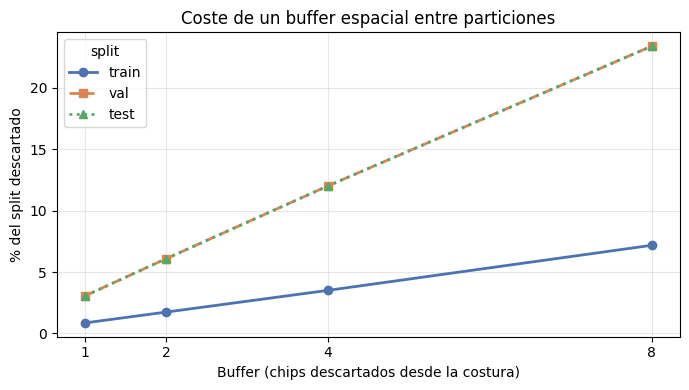

In [18]:
# val y test tienen curvas casi idénticas: distinguimos con estilo de línea
ESTILOS = {"train": ("-", "o"), "val": ("--", "s"), "test": (":", "^")}

fig, ax = plt.subplots(figsize=(7, 4))
for nombre in SPLITS:
    sub = seam_report[seam_report["split"] == nombre]
    linea, marca = ESTILOS[nombre]
    ax.plot(sub["buffer_chips"], sub["pct"], ls=linea, marker=marca, lw=2,
            color=SPLIT_COLORS[nombre], label=nombre)

ax.set_xlabel("Buffer (chips descartados desde la costura)")
ax.set_ylabel("% del split descartado")
ax.set_title("Coste de un buffer espacial entre particiones")
ax.set_xticks(list(BUFFER_STEPS))
ax.grid(alpha=0.3)
ax.legend(title="split")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spatial_validation_seam_buffer_cost.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Mapa del mosaico

Visualización de los 12 rásteres en coordenadas geográficas, coloreados por split, y de la
rejilla de 111 584 chips con las costuras marcadas.

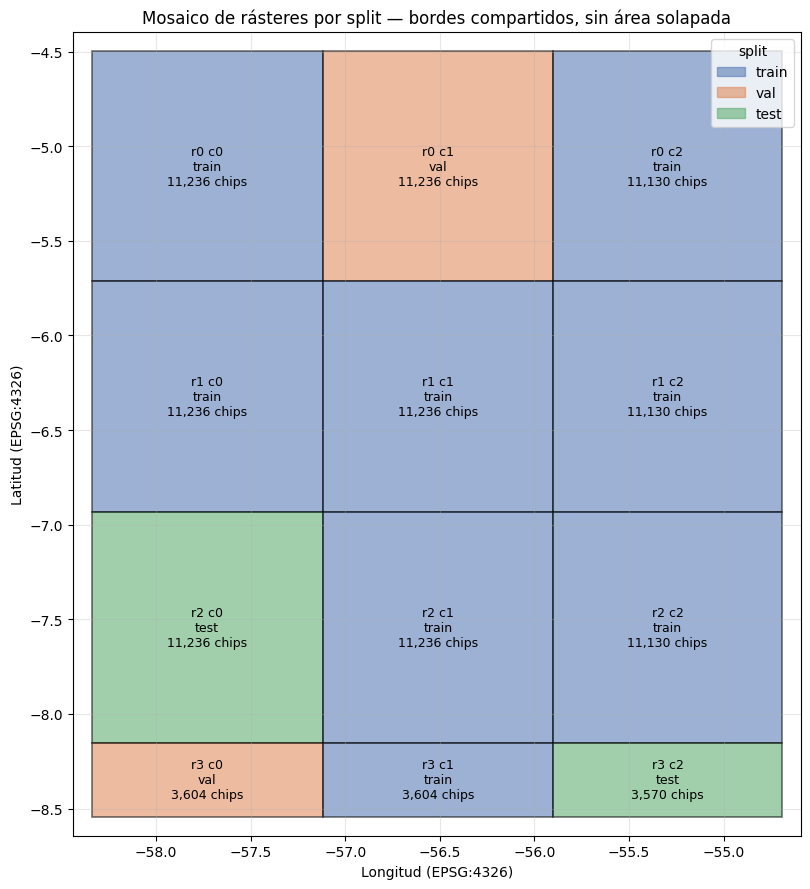

In [19]:
fig, ax = plt.subplots(figsize=(9, 9))

for tif, row in footprints.iterrows():
    ax.add_patch(mpatches.Rectangle(
        (row.xmin, row.ymin), row.ancho_deg, row.alto_deg,
        facecolor=SPLIT_COLORS[row.split], edgecolor="black",
        linewidth=1.2, alpha=0.55,
    ))
    ax.text(
        row.xmin + row.ancho_deg / 2, row.ymin + row.alto_deg / 2,
        f"r{row.grid_row} c{row.grid_col}\n{row.split}\n{row.n_chips:,} chips",
        ha="center", va="center", fontsize=9,
    )

ax.set_xlim(footprints["xmin"].min() - 0.1, footprints["xmax"].max() + 0.1)
ax.set_ylim(footprints["ymin"].min() - 0.1, footprints["ymax"].max() + 0.1)
ax.set_xlabel("Longitud (EPSG:4326)")
ax.set_ylabel("Latitud (EPSG:4326)")
ax.set_title("Mosaico de rásteres por split — bordes compartidos, sin área solapada")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend(
    handles=[mpatches.Patch(color=SPLIT_COLORS[s], label=s, alpha=0.55) for s in SPLITS],
    title="split", loc="upper right",
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spatial_validation_mosaic.png", dpi=150, bbox_inches="tight")
plt.show()

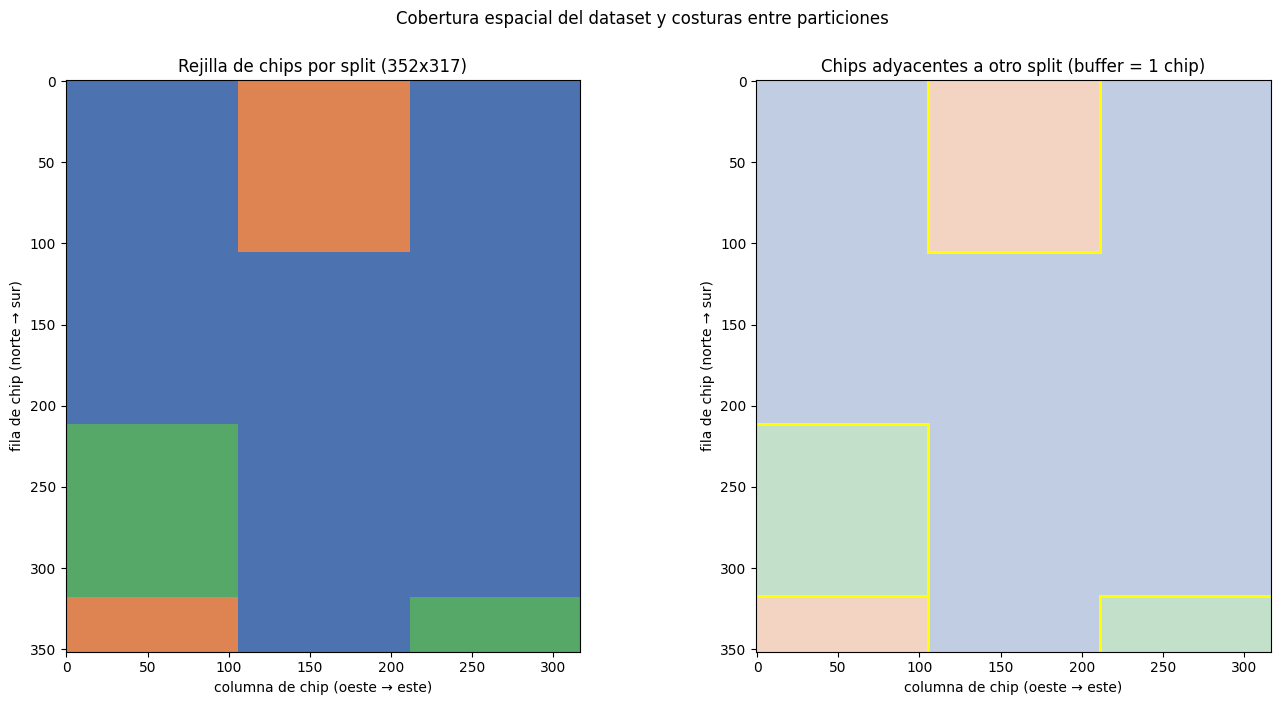

In [20]:
masks_k1 = chips_contaminados(1)
costura = np.zeros_like(grid, dtype=bool)
for nombre in SPLITS:
    costura |= masks_k1[nombre]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

cmap = mcolors.ListedColormap(["white"] + [SPLIT_COLORS[s] for s in SPLITS])
axes[0].imshow(grid, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")
axes[0].set_title(f"Rejilla de chips por split ({N_Y}x{N_X})")

overlay = np.where(costura, 1, 0)
axes[1].imshow(grid, cmap=cmap, vmin=0, vmax=3, interpolation="nearest", alpha=0.35)
axes[1].imshow(np.ma.masked_where(~costura, overlay), cmap="autumn",
               interpolation="nearest", vmin=0, vmax=1)
axes[1].set_title("Chips adyacentes a otro split (buffer = 1 chip)")

for ax in axes:
    ax.set_xlabel("columna de chip (oeste → este)")
    ax.set_ylabel("fila de chip (norte → sur)")

plt.suptitle("Cobertura espacial del dataset y costuras entre particiones", y=1.0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spatial_validation_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Test 7 — Consistencia de los manifiestos de `05_model_input`

Los notebooks de entrenamiento no leen `manifest_with_split.csv`, sino los tres manifiestos
separados de `data/05_model_input/`. Verificamos que esos tres ficheros son una partición
exacta: sin duplicados internos, sin intersección entre ellos y con la unión igual al
manifiesto completo.

In [21]:
manifiestos = {
    split: pd.read_csv(DATA_MODEL_INPUT / f"manifest_{split}.csv")
    for split in SPLITS
}

filas = []
for split, m in manifiestos.items():
    filas.append({
        "split": split,
        "chips": len(m),
        "png_path_duplicados": int(m["png_path"].duplicated().sum()),
        "rasteres": m["tif_source"].nunique(),
        "splits_declarados": m["split"].unique().tolist(),
    })
print(pd.DataFrame(filas).to_string(index=False))

conjuntos = {split: set(m["png_path"]) for split, m in manifiestos.items()}
intersecciones = {
    f"{a}∩{b}": len(conjuntos[a] & conjuntos[b])
    for a, b in itertools.combinations(SPLITS, 2)
}
rasteres = {split: set(m["tif_source"]) for split, m in manifiestos.items()}
inter_rasteres = {
    f"{a}∩{b}": len(rasteres[a] & rasteres[b])
    for a, b in itertools.combinations(SPLITS, 2)
}

print("\nIntersección de chips  :", intersecciones)
print("Intersección de rásteres:", inter_rasteres)

union = set().union(*conjuntos.values())
print(f"\nUnión de los tres manifiestos: {len(union):,} chips")
print(f"Manifiesto completo          : {len(df):,} chips")
print(f"Coinciden                    : {union == set(df['png_path'])}")

total_inter = sum(intersecciones.values()) + sum(inter_rasteres.values())
dup_internos = sum(f["png_path_duplicados"] for f in filas)

registrar(
    "8. Partición train/val/test",
    "OK" if (total_inter == 0 and dup_internos == 0 and union == set(df["png_path"])) else "FALLO",
    "los tres manifiestos son disjuntos, sin duplicados internos y cubren el 100% de los chips"
    if total_inter == 0 and dup_internos == 0 and union == set(df["png_path"])
    else f"{total_inter} elementos compartidos entre splits, {dup_internos} duplicados internos",
)

split  chips  png_path_duplicados  rasteres splits_declarados
train  81938                    0         8           [train]
  val  14840                    0         2             [val]
 test  14806                    0         2            [test]

Intersección de chips  : {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
Intersección de rásteres: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}

Unión de los tres manifiestos: 111,584 chips
Manifiesto completo          : 111,584 chips
Coinciden                    : True


[OK] 8. Partición train/val/test — los tres manifiestos son disjuntos, sin duplicados internos y cubren el 100% de los chips


## 13. Aclaración — qué mide realmente `overlap_ratio`

En el EDA (`01_eda_dataset`, sección 10) la columna `overlap_ratio` se interpretó como
solapamiento espacial entre chips. **No lo es.** Al cruzarla con la etiqueta se ve que mide la
fracción del área del chip intersecada por los polígonos de garimpo, y que es exactamente lo
que define la etiqueta mediante un umbral. Lo comprobamos aquí para evitar que la confusión se
propague a los informes.

In [22]:
print(df.groupby("label_str")["overlap_ratio"].describe().round(6).to_string())

umbral_inf = float(df.loc[df["label_str"] == "com_garimpo", "overlap_ratio"].min())
umbral_sup = float(df.loc[df["label_str"] == "sem_garimpo", "overlap_ratio"].max())
print(f"\nmín(overlap_ratio | com_garimpo) = {umbral_inf:.6f}")
print(f"máx(overlap_ratio | sem_garimpo) = {umbral_sup:.6f}")
print(f"-> umbral de etiquetado ≈ {(umbral_inf + umbral_sup) / 2:.4f} "
      f"({(umbral_inf + umbral_sup) / 2 * 100:.1f}% del área del chip)")

separable = umbral_sup < umbral_inf
registrar(
    "9. Semántica de overlap_ratio",
    "OK" if separable else "AVISO",
    f"overlap_ratio es la intersección con polígonos de garimpo y separa las clases con "
    f"umbral ≈ {(umbral_inf + umbral_sup) / 2:.3f}; no mide solapamiento entre chips"
    if separable
    else "las clases no son separables por overlap_ratio: revisar el etiquetado",
)

por_encima = int((df["overlap_ratio"] > 1.0 + 1e-6).sum())
registrar(
    "9b. Rango de overlap_ratio",
    "OK" if por_encima == 0 else "AVISO",
    f"{por_encima:,} chips con overlap_ratio > 1 (máx {df['overlap_ratio'].max():.2f}): "
    f"los polígonos de garimpo se suman sin disolver, no invalida la etiqueta binaria"
    if por_encima
    else "todos los valores en [0, 1]",
)

               count      mean       std       min       25%  50%  75%       max
label_str                                                                       
com_garimpo  55541.0  1.003981  0.274265  0.050329  0.999998  1.0  1.0  3.310692
sem_garimpo  56043.0  0.000227  0.002678  0.000000  0.000000  0.0  0.0  0.049813

mín(overlap_ratio | com_garimpo) = 0.050329
máx(overlap_ratio | sem_garimpo) = 0.049813
-> umbral de etiquetado ≈ 0.0501 (5.0% del área del chip)
[OK] 9. Semántica de overlap_ratio — overlap_ratio es la intersección con polígonos de garimpo y separa las clases con umbral ≈ 0.050; no mide solapamiento entre chips
[AVISO] 9b. Rango de overlap_ratio — 6,201 chips con overlap_ratio > 1 (máx 3.31): los polígonos de garimpo se suman sin disolver, no invalida la etiqueta binaria


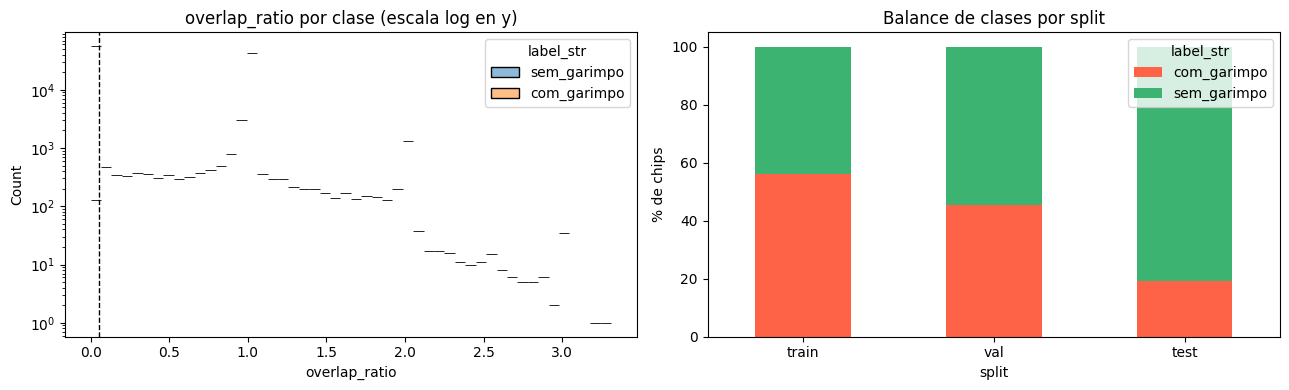

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df, x="overlap_ratio", hue="label_str", bins=50,
             log_scale=(False, True), ax=axes[0])
axes[0].axvline((umbral_inf + umbral_sup) / 2, color="black", ls="--", lw=1)
axes[0].set_title("overlap_ratio por clase (escala log en y)")

ratio_split = (
    df.groupby(["split", "label_str"]).size().unstack(fill_value=0)
)
ratio_split = ratio_split.div(ratio_split.sum(axis=1), axis=0).mul(100)
ratio_split.loc[list(SPLITS)].plot(kind="bar", stacked=True, ax=axes[1],
                                   color=["tomato", "mediumseagreen"])
axes[1].set_ylabel("% de chips")
axes[1].set_title("Balance de clases por split")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "spatial_validation_labels.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Nota — consistencia de la ruta de los chips

`src/data/dataset.py::create_dataloaders()` construye `chips_dir` como
`data/Dataset/datasets/amazonia_garimpo/dataset_amazonia_garimpo_binario`, mientras que los
notebooks `01` y `03` usan `data/01_raw/dataset_amazonia_garimpo_binario`. Solo comprobamos y
reportamos: la corrección corresponde a `src/` o a los notebooks de entrenamiento, que no se
tocan aquí.

In [24]:
RUTAS_CANDIDATAS = {
    "notebooks 01/03 y este": Path("../data/01_raw/dataset_amazonia_garimpo_binario"),
    "src/data/dataset.py": Path("../data/Dataset/datasets/amazonia_garimpo/dataset_amazonia_garimpo_binario"),
}

existentes = []
for etiqueta, ruta in RUTAS_CANDIDATAS.items():
    existe = ruta.exists()
    print(f"  {'OK   ' if existe else 'FALTA'}  {etiqueta:<24} -> {ruta}")
    if existe:
        existentes.append(etiqueta)

muestra_paths = df["png_path"].sample(min(500, len(df)), random_state=RANDOM_STATE)
faltantes = int(sum(not (CHIPS_DIR / p).exists() for p in muestra_paths))

registrar(
    "10. Existencia de los PNG (muestra)",
    "OK" if faltantes == 0 else "FALLO",
    f"{len(muestra_paths)} rutas muestreadas desde {CHIPS_DIR}, {faltantes} inexistentes",
)

registrar(
    "10b. Coherencia de rutas entre notebooks y src/",
    "OK" if len(existentes) == len(RUTAS_CANDIDATAS) else "AVISO",
    f"solo existe la ruta de '{existentes[0]}'; create_dataloaders() apunta a otra carpeta"
    if len(existentes) == 1
    else "todas las rutas candidatas existen",
)

  OK     notebooks 01/03 y este   -> ..\data\01_raw\dataset_amazonia_garimpo_binario
  FALTA  src/data/dataset.py      -> ..\data\Dataset\datasets\amazonia_garimpo\dataset_amazonia_garimpo_binario
[OK] 10. Existencia de los PNG (muestra) — 500 rutas muestreadas desde ..\data\01_raw\dataset_amazonia_garimpo_binario, 0 inexistentes
[AVISO] 10b. Coherencia de rutas entre notebooks y src/ — solo existe la ruta de 'notebooks 01/03 y este'; create_dataloaders() apunta a otra carpeta


## 15. Veredicto y exportación del informe

In [25]:
informe = pd.DataFrame(CHECKS)
resumen = informe["estado"].value_counts().reindex(["OK", "AVISO", "FALLO"], fill_value=0)

print("═══ Informe de validación espacial ═══\n")
print(informe.to_string(index=False))
print(f"\n  OK: {resumen['OK']}   AVISO: {resumen['AVISO']}   FALLO: {resumen['FALLO']}")

if resumen["FALLO"] == 0:
    print("\nVEREDICTO: los 12 rásteres son imágenes de zonas geográficas distintas.")
    print("           No hay superposición de área, ni chips duplicados, ni territorio")
    print("           compartido entre train / val / test.")
else:
    print("\nVEREDICTO: se han detectado fallos; revisar las filas marcadas como FALLO.")

═══ Informe de validación espacial ═══

                                           test estado                                                                                                                                   detalle
                  0. Integridad de la geometría     OK                                                                             0 chips sin split, 0 valores nulos en columnas de coordenadas
                     0b. Bounding boxes válidas     OK                                                                                    0 bounding boxes degeneradas (xmax<=xmin o ymax<=ymin)
               1. Cada ráster en un único split     OK                                                                                                los 12 rásteres pertenecen a un solo split
                 2. Solapamiento entre rásteres     OK                                                           ninguna pareja de rásteres comparte área; los que se tocan sólo comparten b

In [26]:
OUT_FOOTPRINTS = DATA_REPORTING / "spatial_validation_footprints.csv"
OUT_PAIRS = DATA_REPORTING / "spatial_validation_raster_pairs.csv"
OUT_SEAM = DATA_REPORTING / "spatial_validation_seam_buffer.csv"
OUT_CHECKS = DATA_REPORTING / "spatial_validation_report.csv"

footprints.reset_index().to_csv(OUT_FOOTPRINTS, index=False)
pares.to_csv(OUT_PAIRS, index=False)
seam_report.to_csv(OUT_SEAM, index=False)
informe.to_csv(OUT_CHECKS, index=False)

for ruta in (OUT_FOOTPRINTS, OUT_PAIRS, OUT_SEAM, OUT_CHECKS):
    print(f"Guardado: {ruta}")

print("\nFiguras:")
for nombre in (
    "spatial_validation_mosaic.png",
    "spatial_validation_grid.png",
    "spatial_validation_seam_buffer_cost.png",
    "spatial_validation_labels.png",
):
    print(f"Guardado: {FIGURES_DIR / nombre}")

Guardado: ..\data\08_reporting\spatial_validation_footprints.csv
Guardado: ..\data\08_reporting\spatial_validation_raster_pairs.csv
Guardado: ..\data\08_reporting\spatial_validation_seam_buffer.csv
Guardado: ..\data\08_reporting\spatial_validation_report.csv

Figuras:
Guardado: ..\reports\figures\spatial_validation_mosaic.png
Guardado: ..\reports\figures\spatial_validation_grid.png
Guardado: ..\reports\figures\spatial_validation_seam_buffer_cost.png
Guardado: ..\reports\figures\spatial_validation_labels.png


## 16. Conclusiones

**La preocupación inicial queda descartada.** Los 12 `.tif` no son recortes superpuestos de la
misma escena: son las 12 teselas de una exportación de Google Earth Engine sobre una rejilla
de 4 filas × 3 columnas, con desplazamientos de 13 568 px. Las 66 parejas posibles tienen área
de intersección exactamente cero; las teselas vecinas comparten borde con un hueco de
0,0000000000°, que es el comportamiento correcto de un mosaico.

A nivel de chip la evidencia es aún más fuerte: los 111 584 chips se proyectan sobre una
rejilla global de 352 × 317 = 111 584 celdas con **cobertura del 100 %, cero huecos y cero
colisiones**. Cada chip ocupa una celda exclusiva del territorio, así que no existe ni un solo
píxel de suelo representado dos veces. El *stride* de la ventana deslizante es igual al lado
del chip (128 px), por lo que tampoco hay solape entre chips contiguos, y el muestreo de
hashes MD5 confirma que no hay imágenes clonadas.

En cuanto al split, no hay ninguna fuga por duplicación: ninguna celda del territorio es
reclamada por dos particiones y los tres manifiestos de `05_model_input` son disjuntos y
cubren el total. Los resultados de `train` / `val` / `test` no están inflados por imágenes
repetidas.

**El único punto que merece atención** es la contigüidad del mosaico. Como las teselas se
tocan, unos 2 000 chips (≈ 0,9 % de `train` y ≈ 3,1 % de `val` y `test`) tienen un vecino
inmediato en otra partición. No es duplicación, pero sí autocorrelación espacial en la
costura. Si se quiere blindar la evaluación, la tabla de la sección 10.1 cuantifica el coste
de un buffer: descartar 2 chips de margen (~2,6 km) cuesta 1,7 % de `train` y 6,1 % de
`val` / `test`.

Como observación colateral, `overlap_ratio` **no** mide solapamiento entre chips —mide la
intersección con los polígonos de garimpo y define la etiqueta con un umbral de ≈ 0,05—, y la
ruta de chips en `src/data/dataset.py::create_dataloaders()` no coincide con la que existe en
disco. Ambos puntos quedan documentados sin modificar nada.